In [2]:
# Manejo de datos
import pandas as pd                 # Análisis y manipulación de datos en tablas
import numpy as np                  # Cálculos numéricos y matrices
import os                           # Gestión de rutas de archivos

# Visualización de datos
import matplotlib.pyplot as plt     # Gráficos básicos en 2D
import seaborn as sns               # Gráficos estadísticos mejorados
import plotly.express as px         # Gráficos interactivos simplificados
import plotly.graph_objects as go   # Control avanzado de gráficos en Plotly
import plotly.io as pio             # Interfaz de entrada/salida de Plotly

# Procesado y análisis
from scipy import stats
from scipy.stats import chi2_contingency, norm, ttest_ind, f_oneway # Pruebas de hipótesis y análisis estadístico
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import HDBSCAN
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix,roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta = '/content/drive/MyDrive/PostgradoDataScience'


if os.path.exists(ruta):
    print(f"Contenido de {ruta}:\n")
    archivos = os.listdir(ruta)
    for archivo in archivos:
        print(" -", archivo)
else:
    print(f"La ruta no existe:\n{ruta}")

Contenido de /content/drive/MyDrive/PostgradoDataScience:

 - df_rd_classification.csv
 - df_rd_list.csv
 - df_diseases.csv
 - df_rd_history.csv
 - df_genes.csv
 - df_disease_gene.csv
 - df_rd_phenotypes.csv
 - df_rd_functional_consequences.csv
 - df_rd_epidemiology.csv
 - tsne_hdbscan_2clusters.png
 - tsne_hdbscan_50clusters.png
 - Númerodeenfermedadesporclase.png
 - enfermedadesquepertenecenamultiplesclases.png


In [5]:
orphadata = {}

for archivo in os.listdir(ruta):
    if archivo.endswith('.csv'):
        # Eliminar 'df_' i 'rd_' del nombre del archivo
        nombre_limpio = archivo.replace('.csv', '').replace('df_', '').replace('rd_', '')
        nombre_clave = nombre_limpio.lower().replace(' ', '_')
        ruta_completa = os.path.join(ruta, archivo)

        try:
            df = pd.read_csv(ruta_completa)
            orphadata[nombre_clave] = df
            print(f"Cargado: {nombre_clave} ({df.shape[0]} filas, {df.shape[1]} columnas)")
        except Exception as e:
            print(f"Error al cargar {archivo}: {e}")

Cargado: classification (35 filas, 2 columnas)
Cargado: list (11074 filas, 2 columnas)
Cargado: diseases (27613 filas, 3 columnas)
Cargado: history (6994 filas, 9 columnas)
Cargado: genes (4478 filas, 3 columnas)
Cargado: disease_gene (8193 filas, 9 columnas)
Cargado: phenotypes (114961 filas, 5 columnas)
Cargado: functional_consequences (1046 filas, 3 columnas)
Cargado: epidemiology (16119 filas, 10 columnas)


In [6]:
# En diseases → renombrar 'class_hchId' a 'hchId'
orphadata['diseases'].rename(columns={'class_hchId': 'hchId'}, inplace=True)

# En epidemiology → renombrar 'Code Disease' a 'ORPHAcode'
orphadata['epidemiology'].rename(columns={'Code Disease': 'ORPHAcode'}, inplace=True)

# En disease_gene → renombrar 'name' a 'Gene name' y 'symbol' a 'Gene symbol'
orphadata['disease_gene'].rename(columns={
    'name': 'Gene name',
    'symbol': 'Gene symbol'
}, inplace=True)

# En functional_consequences → renombrar 'Código Orphanet' y 'Nombre'
orphadata['functional_consequences'].rename(columns={
    'Código Orphanet': 'ORPHAcode',
    'Nombre': 'disease_name'
}, inplace=True)

Limpiar columnas sin interés

In [7]:
orphadata['functional_consequences'] = orphadata['functional_consequences'].drop(columns=['Consecuencias Funcionales'])
orphadata['disease_gene'] = orphadata['disease_gene'].drop(columns=['Validation source'])
orphadata['diseases'] = orphadata['diseases'].drop(columns=['hchId'])
orphadata['epidemiology'] = orphadata['epidemiology'].drop(columns=['ValMoy', 'PrevalenceValidationStatus', 'Source'])

In [8]:
# Mostra las columnas de cada tabla
for nombre, df in orphadata.items():
    print(f"\n📄 {nombre} ({df.shape[0]} files):")
    print(list(df.columns))


📄 classification (35 files):
['hchId', 'hchTag']

📄 list (11074 files):
['ORPHAcode', 'Preferred term']

📄 diseases (27613 files):
['ORPHAcode', 'preferredTerm']

📄 history (6994 files):
['data', 'AverageAgeOfOnset', 'Date', 'DisorderGroup', 'ORPHAcode', 'OrphanetURL', 'Preferred term', 'TypeOfInheritance', 'Typology']

📄 genes (4478 files):
['HGNC', 'name', 'symbol']

📄 disease_gene (8193 files):
['ORPHAcode', 'Disorder name', 'Disorder type', 'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus']

📄 phenotypes (114961 files):
['ORPHAcode', 'Disorder', 'HPO_ID', 'HPO_Term', 'Frequency']

📄 functional_consequences (1046 files):
['disease_name', 'ORPHAcode']

📄 epidemiology (16119 files):
['ORPHAcode', 'Preferred term', 'Typology', 'PrevalenceType', 'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic']


In [9]:
# Copiar y renombrar columnas similares para diferenciarlas

lista_final = orphadata['list'].rename(columns={
    'Preferred term': 'Preferred_term_list'
})

functional_consequence_final = orphadata['functional_consequences'].rename(columns={
    'disease_name': 'Disease_name_func'
})

disease_gene_final = orphadata['disease_gene'].rename(columns={
    'Disorder name': 'Disease_name_dg'
})

phenotypes_final = orphadata['phenotypes'].rename(columns={
    'Disorder': 'Disease_name_pheno'
})

diseases_final = orphadata['diseases'].rename(columns={
    'preferredTerm': 'Preferred_term_diseases'
})

epidemiology_final = orphadata['epidemiology'].rename(columns={
    'Preferred term': 'Preferred_term_epi'
})

In [10]:
tablas_finales = {
    'list': lista_final,
    'functional_consequences': functional_consequence_final,
    'disease_gene': disease_gene_final,
    'phenotypes': phenotypes_final,
    'diseases': diseases_final,
    'epidemiology': epidemiology_final
}

In [11]:
print(tablas_finales.keys())

dict_keys(['list', 'functional_consequences', 'disease_gene', 'phenotypes', 'diseases', 'epidemiology'])


In [12]:
for nombre, df in tablas_finales.items():
    print(f"\n📄 {nombre} ({df.shape[0]} files):")
    print(list(df.columns))


📄 list (11074 files):
['ORPHAcode', 'Preferred_term_list']

📄 functional_consequences (1046 files):
['Disease_name_func', 'ORPHAcode']

📄 disease_gene (8193 files):
['ORPHAcode', 'Disease_name_dg', 'Disorder type', 'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus']

📄 phenotypes (114961 files):
['ORPHAcode', 'Disease_name_pheno', 'HPO_ID', 'HPO_Term', 'Frequency']

📄 diseases (27613 files):
['ORPHAcode', 'Preferred_term_diseases']

📄 epidemiology (16119 files):
['ORPHAcode', 'Preferred_term_epi', 'Typology', 'PrevalenceType', 'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic']


MERGE

In [13]:
df_merged = tablas_finales['list'] \
    .merge(tablas_finales['diseases'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['phenotypes'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['functional_consequences'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['epidemiology'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['disease_gene'], on='ORPHAcode', how='left')

Merge de las columnas reiterativas

In [14]:
df_merged['Disease_name_unificado'] = df_merged[
    ['Disease_name_func', 'Disease_name_dg', 'Disease_name_pheno']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Disease_name_func', 'Disease_name_dg', 'Disease_name_pheno'], inplace=True)

/tmp/ipython-input-14-3479528273.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].bfill(axis=1).iloc[:, 0]


In [15]:
df_merged['Preferred_term_unificado'] = df_merged[
    ['Preferred_term_list', 'Preferred_term_diseases', 'Preferred_term_epi']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Preferred_term_list', 'Preferred_term_diseases', 'Preferred_term_epi'], inplace=True)

In [16]:
df_merged['Disorder_type_unificado'] = df_merged[
    ['Disorder type', 'Typology']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Disorder type', 'Typology'], inplace=True)

/tmp/ipython-input-16-2913094727.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].bfill(axis=1).iloc[:, 0]


In [ ]:
print(df_merged.columns)

Index(['ORPHAcode', 'HPO_ID', 'HPO_Term', 'Frequency', 'PrevalenceType',
       'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic',
       'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus',
       'Disease_name_unificado', 'Preferred_term_unificado',
       'Disorder_type_unificado'],
      dtype='object')


In [ ]:
df_merged.head()

,ORPHAcode,HPO_ID,HPO_Term,Frequency,PrevalenceType,PrevalenceClass,PrevalenceQualification,PrevalenceGeographic,Gene symbol,Gene name,Gene type,Gene synonyms,Locus,Disease_name_unificado,Preferred_term_unificado,Disorder_type_unificado
0,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
1,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
2,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
3,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
4,166024,HP:0000316,Hypertelorism,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease


In [17]:
# Transformación de las frecuencias cualitativas a valores numéricos
freq_map = {
    "Obligate (100%)": 1.00,                  # 100%
    "Very frequent (99-80%)": 0.895,          # promedio: (99+80)/2 = 89.5%
    "Frequent (79-30%)": 0.545,               # (79+30)/2 = 54.5%
    "Occasional (29-5%)": 0.17,               # (29+5)/2 = 17%
    "Rare (<4%)": 0.02,                       # asumimos 2%
    "Excluded (0%)": 0.0,
    np.nan: np.nan                            # dejamos como NaN real
}

df_merged['frequency_numeric'] = df_merged['Frequency'].map(freq_map).fillna(0)

In [18]:
# Pivotar a matriz enfermedades x síntomas
df_pivot = df_merged.pivot_table(index='ORPHAcode',
                                 columns='HPO_ID',
                                 values='frequency_numeric',
                                 aggfunc='max',
                                 fill_value=0)

In [19]:
# Reducción de dimensionalidad con PCA
pca = PCA(n_components=50)  # puedes ajustar según varianza explicada
X_pca = pca.fit_transform(df_pivot)

In [20]:
# exemple senzill pscykit learn
hdb = HDBSCAN(min_cluster_size=5) #, metric = "manhattan"
hdb.fit(X_pca)
hdb.labels_.shape == (X_pca.shape[0],)
np.unique(hdb.labels_).tolist()

labels_hdb = hdb.labels_

In [21]:
n_clusters = len(np.unique(labels_hdb))
print(f"Número de clusters encontrados: {n_clusters}")

Número de clusters encontrados: 3


In [30]:
# hago un loop para ver cuantos clusters crea para cada min_cluster_size distinto
range_n = range(2, 12)
scores = []

for k in range_n:
    hdb = HDBSCAN(min_cluster_size=k)
    hdb.fit(X_pca)
    labels = hdb.labels_
    n_clusters = len(np.unique(labels)) - 1
    print(f"k={k}, Número de clusters encontrados={n_clusters}")

k=2, Número de clusters encontrados=551
k=3, Número de clusters encontrados=118
k=4, Número de clusters encontrados=51
k=5, Número de clusters encontrados=2
k=6, Número de clusters encontrados=12
k=7, Número de clusters encontrados=7
k=8, Número de clusters encontrados=2
k=9, Número de clusters encontrados=2
k=10, Número de clusters encontrados=2
k=11, Número de clusters encontrados=2


El cambio se produce en 5, asi que me quedo con 5.

El -1 no es cluster, es ruido, es decir los puntos que no puede agrupar en ningun cluster. del 0 al numero que marque son los clusters







Ahora quiero ver con que min_cluster_size el modelo obtiene mejor validity score

In [31]:
from hdbscan.validity import validity_index

range_n = range(2, 12)
validity_scores = []

for k in range_n:
    hdb = HDBSCAN(min_cluster_size=k)
    hdb.fit(X_pca)
    score = validity_index(X_pca, hdb.labels_)
    validity_scores.append(score)
    print(f"min_cluster_size={k}, Validity Index={score:.4f}")

/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[


min_cluster_size=2, Validity Index=0.1107


/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[


min_cluster_size=3, Validity Index=0.0577


/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[


min_cluster_size=4, Validity Index=0.0384


/usr/local/lib/python3.11/dist-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[


min_cluster_size=5, Validity Index=0.2106
min_cluster_size=6, Validity Index=0.0178
min_cluster_size=7, Validity Index=0.0139
min_cluster_size=8, Validity Index=0.0637
min_cluster_size=9, Validity Index=0.0725
min_cluster_size=10, Validity Index=0.0706
min_cluster_size=11, Validity Index=0.0764


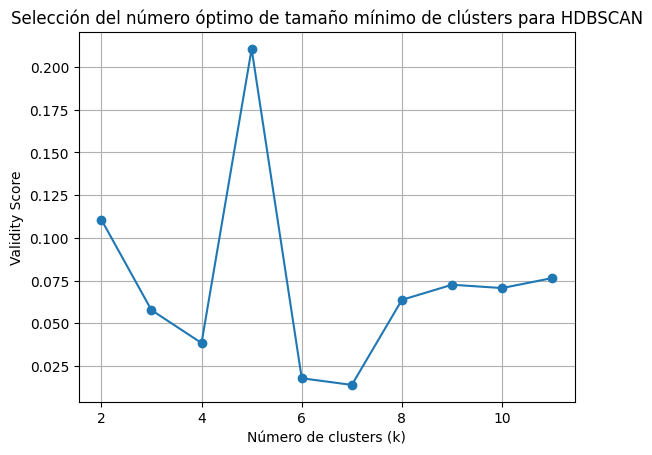

In [29]:
plt.plot(range_n, validity_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Validity Score")
plt.title("Selección del número óptimo de tamaño mínimo de clústers para HDBSCAN")
plt.grid(True)
plt.show()

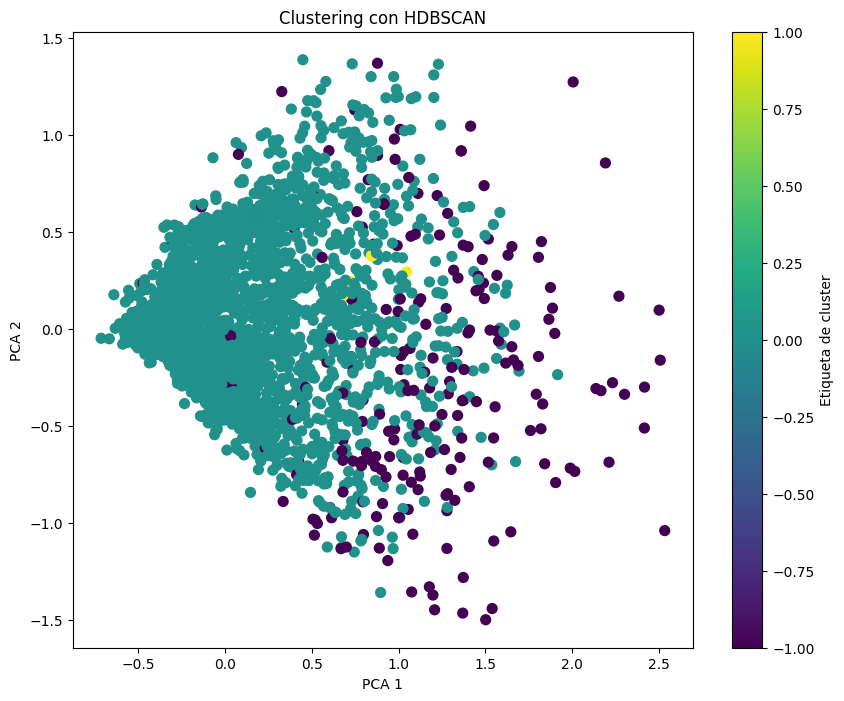

In [ ]:
from sklearn.decomposition import PCA

# Reducir a 2 dimensiones con PCA para visualizar
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_pca)

# Graficar resultados
plt.figure(figsize=(10, 8))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=hdb.labels_, cmap='viridis', s=50)
plt.colorbar(label='Etiqueta de cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clustering con HDBSCAN')
plt.show()

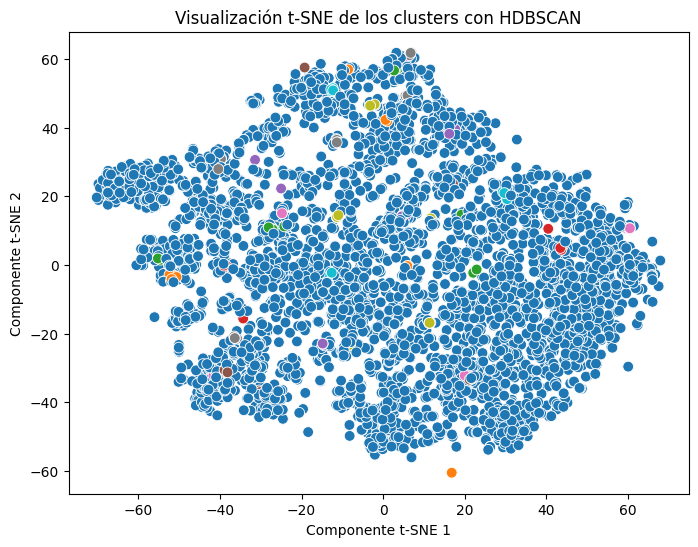

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

# Aplicar t-SNE sobre los datos reducidos con PCA
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X_pca)

# Obtener etiquetas de HDBSCAN
clusters = hdb.labels_

# Graficar
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=clusters, palette='tab10', s=60, legend=False)
plt.title("Visualización t-SNE de los clusters con HDBSCAN")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
#plt.legend(title="Cluster")
plt.savefig("tsne_hdbscan_50clusters.png", format="png", dpi=300)
plt.show()


<Figure size 640x480 with 0 Axes>

In [ ]:
import os
print(os.getcwd())

/content


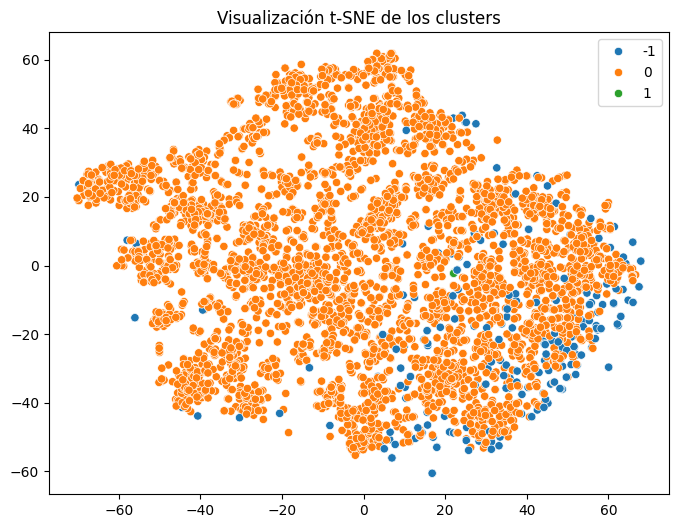

In [ ]:
# Visualizamos con t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=clusters, palette='tab10')
plt.title("Visualización t-SNE de los clusters")
plt.show()